<a href="https://colab.research.google.com/github/SkyWarLimit/PCVK26_17_MIhsanR/blob/main/Week06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**PERSIAPAN DATA**

In [1]:
NAMA = 'Muhammad Ihsan Rahmatullah'
NIM = '244107020218'
print(NAMA, NIM)

Muhammad Ihsan Rahmatullah 244107020218


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

In [13]:
# Mendefinisikan fungsi show_side_by_side
def show_side_by_side(images, titles, figsize=(15,5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        if len(img.shape) == 2: # grayscale
            plt.subplot(1, len(images), i+1)
            plt.imshow(img, cmap="gray")
        else: # color
            plt.subplot(1, len(images), i+1)
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()

**PRAKTIKUM D**

In [6]:
# Membuat fungsi konvolusi tanpa library
def convolution2d(image, kernel, stride=1, padding=0):

    # Menambahkan padding jika nilai padding > 0
    if padding > 0:
        image = np.pad(image, pad_width=padding, mode='constant', constant_values=0)

    img_h, img_w = image.shape
    kernel_h, kernel_w = kernel.shape

    # Hitung dimensi output
    out_h = int((img_h - kernel_h) / stride) + 1
    out_w = int((img_w - kernel_w) / stride) + 1

    output = np.zeros((out_h, out_w), dtype=np.float32)

    # Proses konvolusi
    for y in range(out_h):
        for x in range(out_w):
            output[y, x] = np.sum(
                image[y*stride : y*stride+kernel_h, x*stride : x*stride+kernel_w] * kernel
            )

    # Normalisasi nilai piksel ke rentang 0-255
    return np.clip(output, 0, 255).astype(np.uint8)

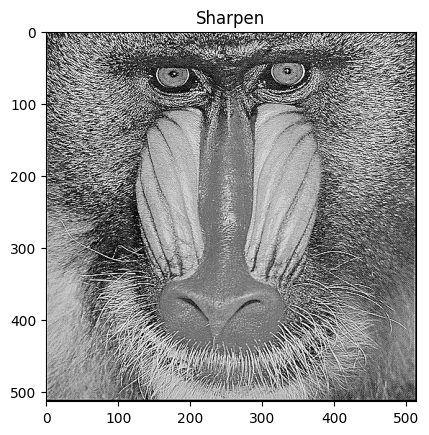

In [7]:
img = cv.imread('/content/drive/MyDrive/PCVK/mandrill.tiff')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# image sharpen
kernel_sharpen = np.array([[0,-1,0],
                           [-1,5,-1],
                           [0,-1,0]])

# Memanggil fungsi konvolusi
res_sharpen = convolution2d(img_gray, kernel_sharpen, 1, 2)

# Tampilkan hasil
plt.imshow(res_sharpen, cmap='gray')
plt.title('Sharpen')
plt.show()

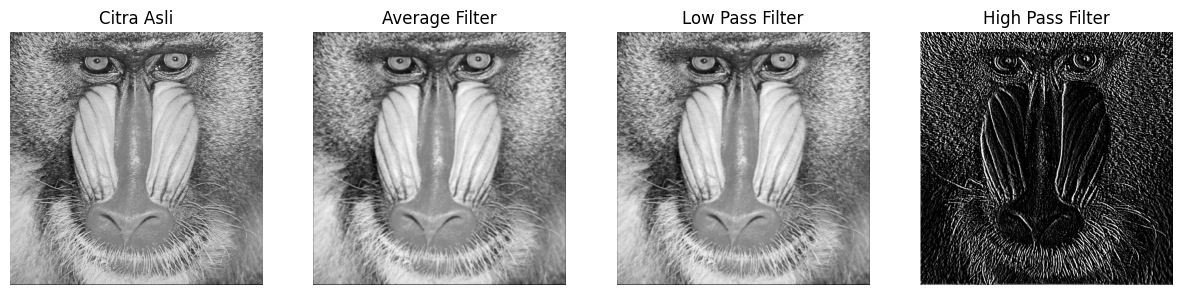

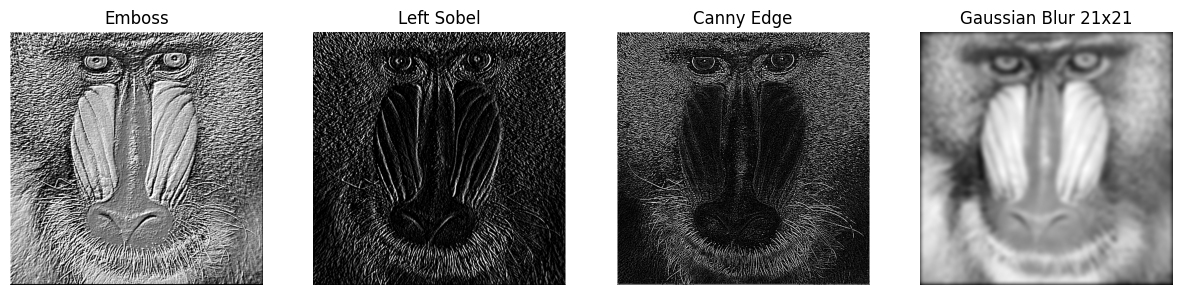

In [14]:
# Definisi beberapa contoh lain dari kernel
kernel_avg = np.array([[1, 1, 1],
                       [1, 1, 1],
                       [1, 1, 1]]) / 9.0

kernel_lpf = np.array([[1, 1, 1],
                       [1, 4, 1],
                       [1, 1, 1]]) / 12.0

kernel_hpf = np.array([[-1, 0, 1],
                       [-1, 0, 3],
                       [-3, 0, 1]])

kernel_emboss = np.array([[-2, -1, 0],
                          [-1,  1, 1],
                          [ 0,  1, 2]])

kernel_left_sobel = np.array([[1, 0, -1],
                              [2, 0, -2],
                              [1, 0, -1]])

kernel_canny = np.array([[-1, -1, -1],
                         [-1,  8, -1],
                         [-1, -1, -1]])

# Generate 21x21 Gaussian Blur
kernel_size = 21
sigma = math.sqrt(kernel_size)
gaussian_kernel = cv.getGaussianKernel(kernel_size, sigma)
gauss_kernel = gaussian_kernel @ gaussian_kernel.transpose()

# Eksekusi konvolusi untuk masing-masing kernel
res_avg = convolution2d(img_gray, kernel_avg, 1, 1)
res_lpf = convolution2d(img_gray, kernel_lpf, 1, 1)
res_hpf = convolution2d(img_gray, kernel_hpf, 1, 1)
res_emboss = convolution2d(img_gray, kernel_emboss, 1, 1)
res_left_sobel = convolution2d(img_gray, kernel_left_sobel, 1, 1)
res_canny_edge = convolution2d(img_gray, kernel_canny, 1, 1)
res_gauss_blur = convolution2d(img_gray, gauss_kernel, 1, int(kernel_size/2))

# Menampilkan hasil setiap kernel menggunakan fungsi show_side_by_side
show_side_by_side([img_gray, res_avg, res_lpf, res_hpf],
                  ["Citra Asli", "Average Filter", "Low Pass Filter", "High Pass Filter"])

show_side_by_side([res_emboss, res_left_sobel, res_canny_edge, res_gauss_blur],
                  ["Emboss", "Left Sobel", "Canny Edge", "Gaussian Blur 21x21"])

**PRAKTIKUM E**

**PERCOBAAN 1**

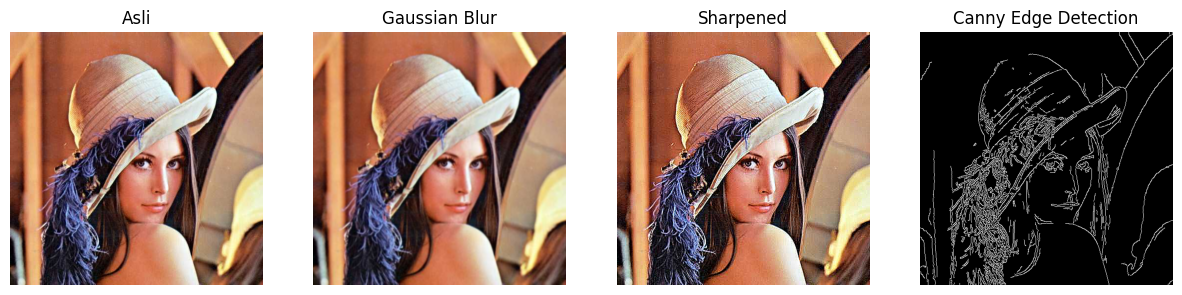

In [15]:
img_lena = cv.imread("/content/drive/MyDrive/PCVK/lena.jpg")

blur = cv.GaussianBlur(img_lena, (7,7), 1)
edges = cv.Canny(cv.cvtColor(img_lena, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel = np.array([[0,-1,0], [-1,5,-1], [0,-1,0]])
sharpened = cv.filter2D(img_lena, -1, sharpen_kernel)

show_side_by_side([img_lena, blur, sharpened, edges],
                  ["Asli", "Gaussian Blur", "Sharpened", "Canny Edge Detection"])

**PERCOBAAN 2**

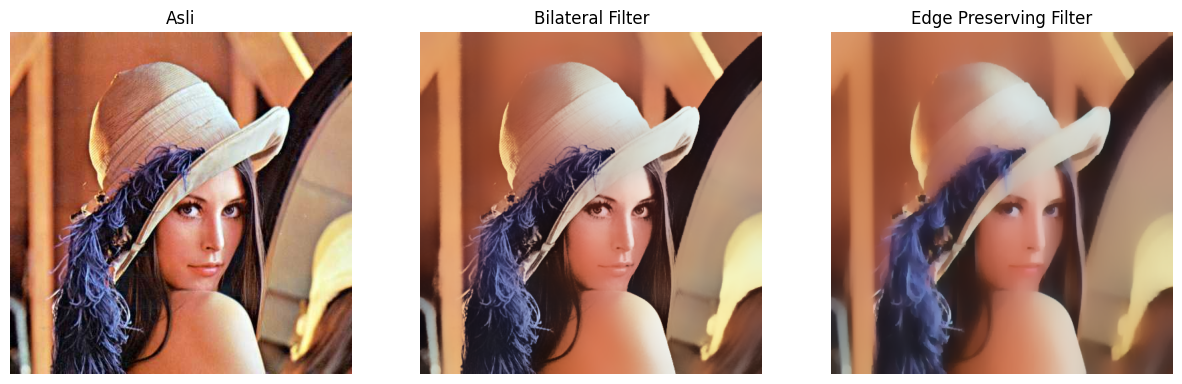

In [16]:
# Filter Modern dari OpenCV
# Bilateral Filter (edge-preserving)
bilateral = cv.bilateralFilter(img_lena, 50, 100, 100)

# Edge Preserving Filter (alternatif Guided Filter)
edge_preserve = cv.edgePreservingFilter(img_lena, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side([img_lena, bilateral, edge_preserve],
                  ["Asli", "Bilateral Filter", "Edge Preserving Filter"])

**PERCOBAAN 3**

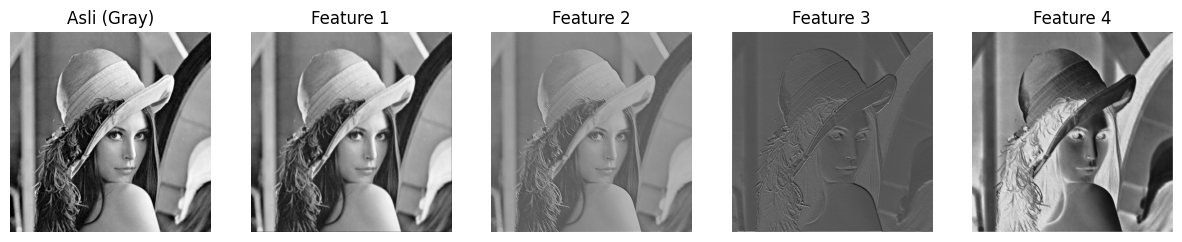

In [17]:
import torch
import torch.nn as nn

# Filter Feature Map yang digunakan pada CNN
img_gray_lena = cv.cvtColor(img_lena, cv.COLOR_BGR2GRAY)

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        return self.conv1(x)

model = SimpleCNN()

# Ubah gambar ke tensor
img_tensor = torch.tensor(img_gray_lena, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

# Hasil CNN
with torch.no_grad():
    features = model(img_tensor)

# Visualisasi feature maps
feature_maps = [features[0, i].numpy() for i in range(features.shape[1])]
show_side_by_side([img_gray_lena] + feature_maps,
                  ["Asli (Gray)"] + [f"Feature {i+1}" for i in range(len(feature_maps))])

**PERCOBAAN 4**

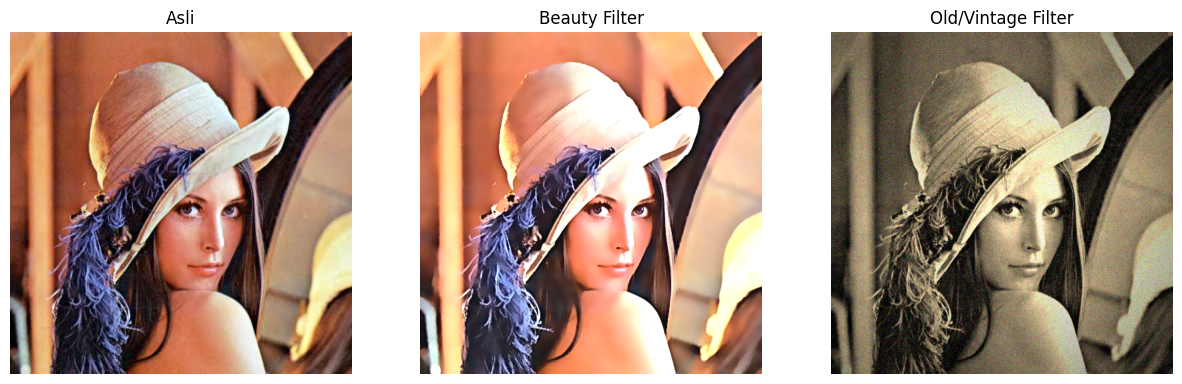

In [19]:
# 1. Beauty Filter
# Smoothing kulit dengan bilateral filter
smooth = cv.bilateralFilter(img_lena, d=15, sigmaColor=75, sigmaSpace=75)
# Unsharp masking (pertajam mata/bibir)
gaussian = cv.GaussianBlur(smooth, (0,0), 3)
sharpened = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)
# Brightness & contrast
alpha = 1.2 # contrast
beta = 15 # brightness
beauty = cv.convertScaleAbs(sharpened, alpha=alpha, beta=beta)

# 2. Old/Vintage Filter
# Sepia tone
sepia_kernel = np.array([[0.272, 0.534, 0.131],
                         [0.349, 0.686, 0.168],
                         [0.393, 0.769, 0.189]])
sepia = cv.transform(img_lena, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

# Vignette
rows, cols = img_lena.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols*0.6)
kernel_y = cv.getGaussianKernel(rows, rows*0.6)
kernel = kernel_y * kernel_x.T
mask = kernel / kernel.max()
vignette = np.copy(sepia)
for i in range(3):
    vignette[:,:,i] = vignette[:,:,i] * mask

# Noise/Grain
noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)

show_side_by_side([img_lena, beauty, old_img], ["Asli", "Beauty Filter", "Old/Vintage Filter"])

**PERCOBAAN 5**

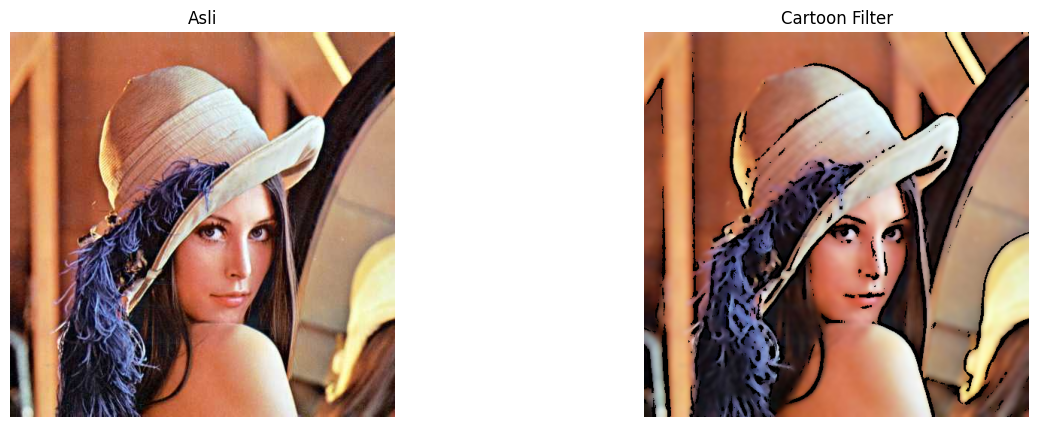

In [20]:
# Filter Anime / Cartoon
# Edge detection (pahat median blur dulu agar gambar menjadi lebih halus)
gray = cv.cvtColor(img_lena, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray, 7)
edges = cv.adaptiveThreshold(gray_blur, 255,
                             cv.ADAPTIVE_THRESH_MEAN_C,
                             cv.THRESH_BINARY, 9, 9)

# Bilateral Filter untuk smoothing warna
color = cv.bilateralFilter(img_lena, d=9, sigmaColor=200, sigmaSpace=200)

# Gabungkan (cartoonize)
cartoon = cv.bitwise_and(color, color, mask=edges)

show_side_by_side([img_lena, cartoon], ["Asli", "Cartoon Filter"])

**PERCOBAAN 6**

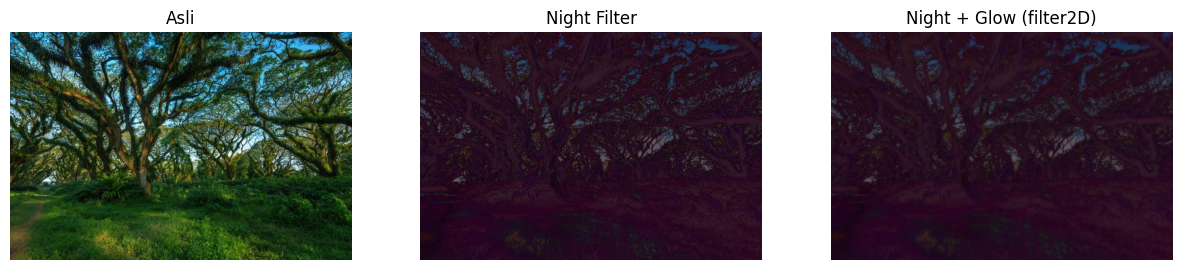

In [22]:
# Night Filter
img_djawatan = cv.imread("/content/drive/MyDrive/PCVK/djawatan.jpg")

# Gelapkan (contrast turun, brightness negatif)
night = cv.convertScaleAbs(img_djawatan, alpha=0.6, beta=-40)

# Tambah bias biru
blue_tint = np.full_like(night, (50, 0, 100)) # BGR
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

# Efek glow di area terang dengan filter2D (blur kernel)
kernel = np.ones((15,15), np.float32) / 225
glow = cv.filter2D(night, -1, kernel)

# Kombinasikan asli + glow
night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

show_side_by_side([img_djawatan, night, night_glow],
                  ["Asli", "Night Filter", "Night + Glow (filter2D)"])

**PERCOBAAN 7**

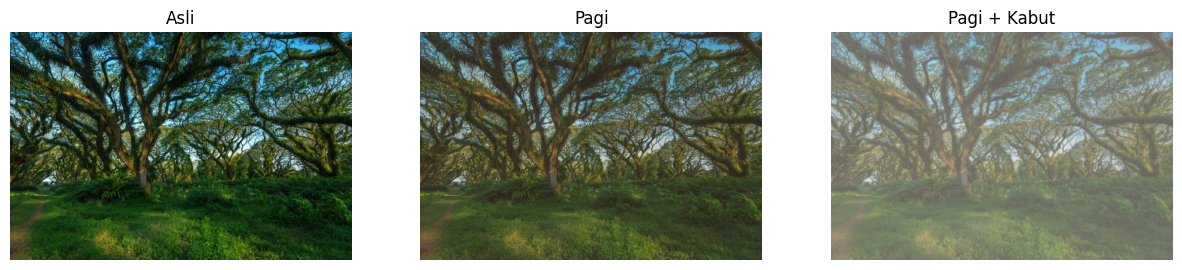

In [23]:
# Filter Suasana Pagi dan Kabut
# Kurangi kontras & cerahkan
alpha = 0.9 # contrast
beta = 20 # brightness
soft = cv.convertScaleAbs(img_djawatan, alpha=alpha, beta=beta)

# Tambahkan warm tone (kemerahan / oranye)
warm_tint = np.full_like(soft, (40, 70, 120)) # BGR
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

# Tambahkan haze (kabut tipis) dengan filter2D
kernel = cv.getGaussianKernel(3, 3)
kernel = kernel @ kernel.T # jadikan 2D kernel
kabut = cv.filter2D(pagi, -1, kernel)

# Tambah layer untuk kabut lebih nyata
white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

show_side_by_side([img_djawatan, pagi, kabut],
                  ["Asli", "Pagi", "Pagi + Kabut"])

**TUGAS PRAKTIKUM 1**

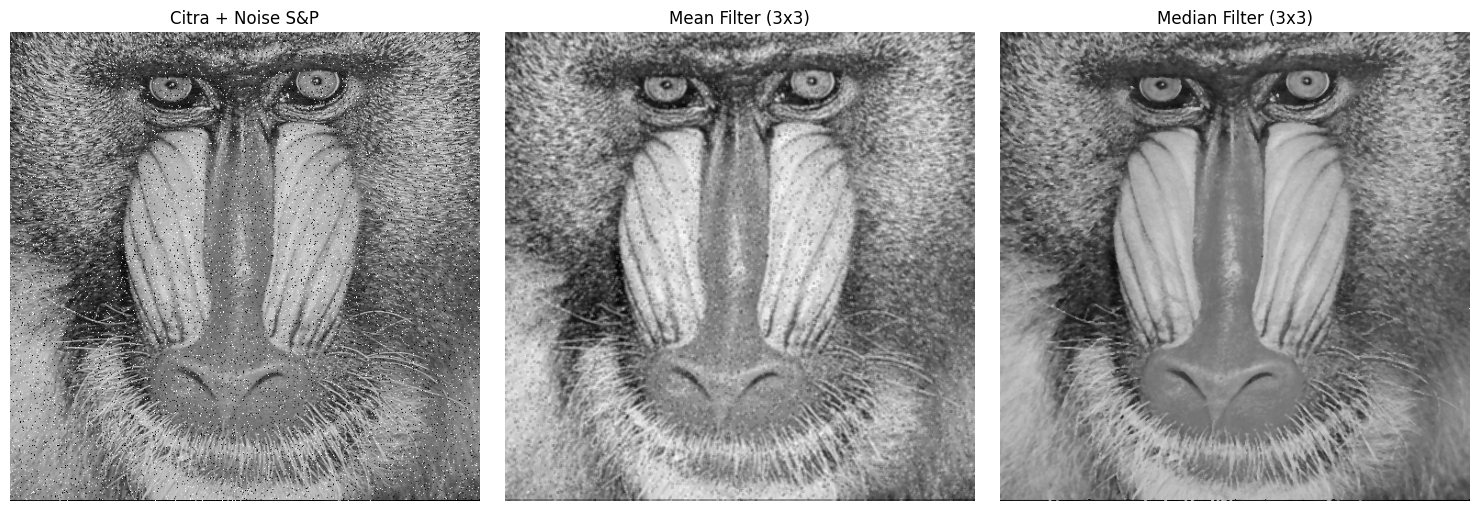

In [27]:
import random

img_gray = cv.imread('/content/drive/MyDrive/PCVK/mandrill.tiff', cv.IMREAD_GRAYSCALE)

# Menambahkan Noise bintik hitam-putih (Salt and Pepper)
img_noise = np.copy(img_gray)
prob = 0.05  # 5% kemungkinan noise
for i in range(img_noise.shape[0]):
    for j in range(img_noise.shape[1]):
        rdn = random.random()
        if rdn < prob / 2:
            img_noise[i][j] = 0      # Pepper (bintik hitam)
        elif rdn < prob:
            img_noise[i][j] = 255    # Salt (bintik putih)

# Terapkan Mean Filter (3x3)
kernel_mean = np.ones((3, 3), np.float32) / 9.0
res_mean = cv.filter2D(img_noise, -1, kernel_mean)

# Terapkan Median Filter (3x3)
res_median = cv.medianBlur(img_noise, 3)

# Menampilkan hasil
plt.figure(figsize=(15, 5))
images_tugas1 = [img_noise, res_mean, res_median]
titles_tugas1 = ['Citra + Noise S&P', 'Mean Filter (3x3)', 'Median Filter (3x3)']

for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.imshow(images_tugas1[i], cmap='gray')
    plt.title(titles_tugas1[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

ANALISA

Berdasarkan hasil visual, Median Filter jauh lebih bersih dalam menghapus noise Salt and Pepper dibandingkan Mean Filter. Hal ini terjadi karena Median Filter mengambil nilai tengah dari piksel tetangganya. Nilai ekstrem dari noise (0 untuk hitam, 255 untuk putih) akan selalu berada di ujung pengurutan dan diabaikan. Sebaliknya, Mean Filter merata-ratakan seluruh piksel, sehingga nilai ekstrem tersebut ikut terhitung dan menyebabkan warna piksel di sekitarnya ikut memudar dan tampak kotor.

**TUGAS PRAKTIKUM 2**

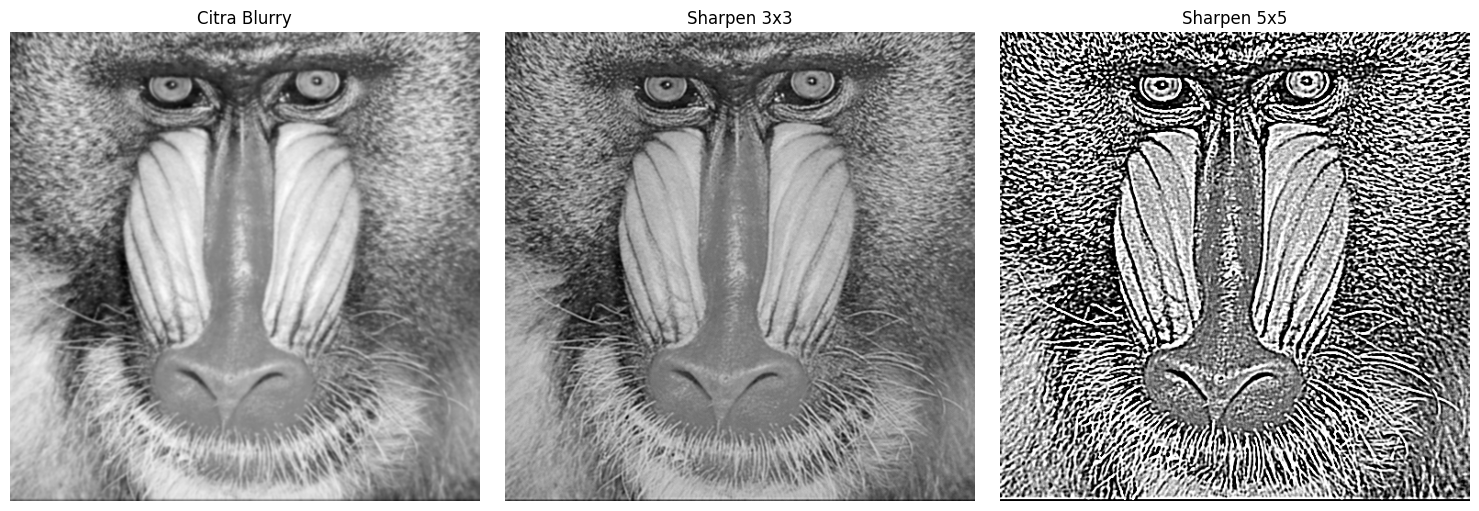

In [28]:
# Membuat citra sedikit buram (blurry) sebagai input simulasi
img_blurry = cv.GaussianBlur(img_gray, (5, 5), 0)

# Buat kernel penajaman 3x3
kernel_sharp_3x3 = np.array([[ 0, -1,  0],
                             [-1,  5, -1],
                             [ 0, -1,  0]])

# Buat kernel penajaman 5x5
kernel_sharp_5x5 = np.array([[-1, -1, -1, -1, -1],
                             [-1, -1, -1, -1, -1],
                             [-1, -1, 25, -1, -1],
                             [-1, -1, -1, -1, -1],
                             [-1, -1, -1, -1, -1]])

# Terapkan filter penajaman pada citra buram
res_sharp_3x3 = cv.filter2D(img_blurry, -1, kernel_sharp_3x3)
res_sharp_5x5 = cv.filter2D(img_blurry, -1, kernel_sharp_5x5)

# Menampilkan hasil evaluasi
plt.figure(figsize=(15, 5))
images_tugas2 = [img_blurry, res_sharp_3x3, res_sharp_5x5]
titles_tugas2 = ['Citra Blurry', 'Sharpen 3x3', 'Sharpen 5x5']

for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.imshow(images_tugas2[i], cmap='gray')
    plt.title(titles_tugas2[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

ANALISA

Evaluasi kejelasan tepi versus kadar noise:
1. Kernel 3x3: Mampu menajamkan batas tepi dengan rapi dan mengembalikan fokus dari citra buram tanpa memunculkan distorsi noise secara berlebihan.
2. Kernel 5x5: Hasil penajaman terlalu agresif, sehingga memunculkan artefak ringing (lingkaran halo) di pinggiran objek dan memperkuat noise tekstur secara berlebihan, membuat gambar tampak sangat kasar.

Kesimpulan: Kernel ukuran 3x3 adalah yang paling optimal untuk digunakan sehari-hari karena menyeimbangkan edge clarity dan meminimalisir noise distortion.

**TUGAS PRAKTIKUM 3**

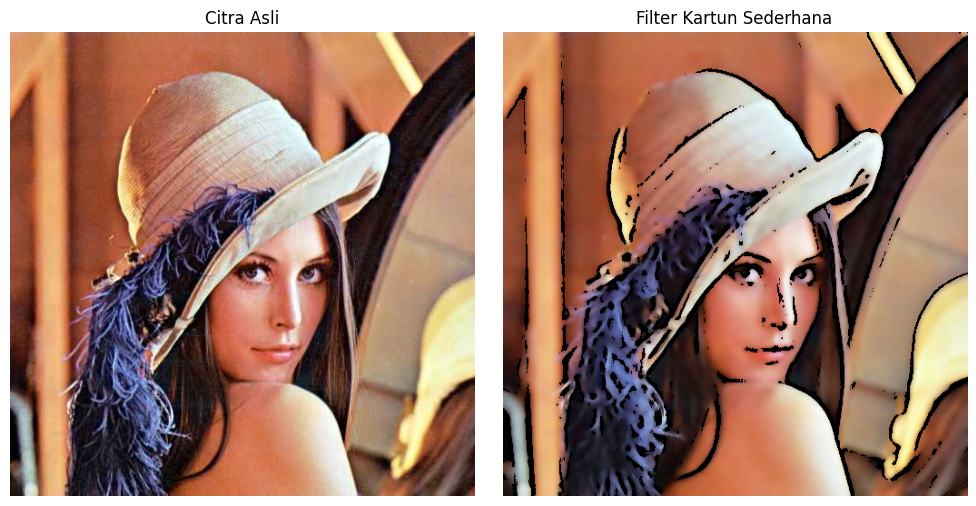

In [30]:
img_color = cv.imread('/content/drive/MyDrive/PCVK/lena.jpg')
img_rgb = cv.cvtColor(img_color, cv.COLOR_BGR2RGB)

def kartun(image):
    # Penghalusan warna menggunakan Bilateral Filter agar area warna menjadi rata
    color = cv.bilateralFilter(image, d=9, sigmaColor=200, sigmaSpace=200)

    # Deteksi garis tepi menggunakan Adaptive Thresholding
    gray = cv.cvtColor(image, cv.COLOR_RGB2GRAY)
    gray_blur = cv.medianBlur(gray, 7)
    edges = cv.adaptiveThreshold(gray_blur, 255,
                                 cv.ADAPTIVE_THRESH_MEAN_C,
                                 cv.THRESH_BINARY, 9, 9)

    # Penggabungan (kombinasi) menggunakan operasi logika
    cartoon_img = cv.bitwise_and(color, color, mask=edges)

    return cartoon_img

# Proses pembuatan kartun
img_kartun = kartun(img_rgb)

# Tampilkan hasil bersebelahan dengan subplot
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Citra Asli")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_kartun)
plt.title("Filter Kartun Sederhana")
plt.axis('off')

plt.tight_layout()
plt.show()